# BÀI LÀM — Đoàn Tân Minh Tân

## Bài 1: Hiểu sâu self-attention

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

VOCAB = ['bad', 'nice', 'cool', 'fast', 'slow', 'good', 'dark', 'warm', 'soft', 'hard']
GOOD_IDX = VOCAB.index('good')
SEQ_LEN = 8
N = 200

X_raw = torch.randint(len(VOCAB), (N, SEQ_LEN))
y = (X_raw == GOOD_IDX).any(dim=1).long()

print('X_raw shape:', X_raw.shape)
print('y shape    :', y.shape)
print(f'Tỉ lệ nhãn 1: {y.float().mean():.2%}')
print('Ví dụ câu [0]:', [VOCAB[i] for i in X_raw[0].tolist()], '→ nhãn', y[0].item())

X_raw shape: torch.Size([200, 8])
y shape    : torch.Size([200])
Tỉ lệ nhãn 1: 51.50%
Ví dụ câu [0]: ['cool', 'warm', 'dark', 'slow', 'dark', 'good', 'bad', 'slow'] → nhãn 1


In [2]:
class SelfAttention(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.embed_dim = embed_dim
        self.W_q = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_k = nn.Linear(embed_dim, embed_dim, bias=False)
        self.W_v = nn.Linear(embed_dim, embed_dim, bias=False)

    def forward(self, x, return_attn=False):
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)
        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.embed_dim)
        attn = F.softmax(scores, dim=-1)
        out = attn @ V
        if return_attn:
            return out, attn
        return out


class AttnClassifier(nn.Module):
    def __init__(self, vocab_size=10, embed_dim=16, num_classes=2):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embed_dim)
        self.attn = SelfAttention(embed_dim)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x, return_attn=False):
        h = self.emb(x)
        if return_attn:
            h, attn_w = self.attn(h, return_attn=True)
        else:
            h = self.attn(h)
        pooled = h.mean(dim=1)
        logits = self.fc(pooled)
        if return_attn:
            return logits, attn_w
        return logits


model_b1 = AttnClassifier()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_b1.parameters(), lr=1e-3)
print('Tham số mô hình:', sum(p.numel() for p in model_b1.parameters()))

Tham số mô hình: 962


Epoch  60  loss = 0.1265  acc = 100.00%
Epoch 120  loss = 0.0146  acc = 100.00%
Epoch 180  loss = 0.0063  acc = 100.00%
Epoch 240  loss = 0.0037  acc = 100.00%
Epoch 300  loss = 0.0024  acc = 100.00%


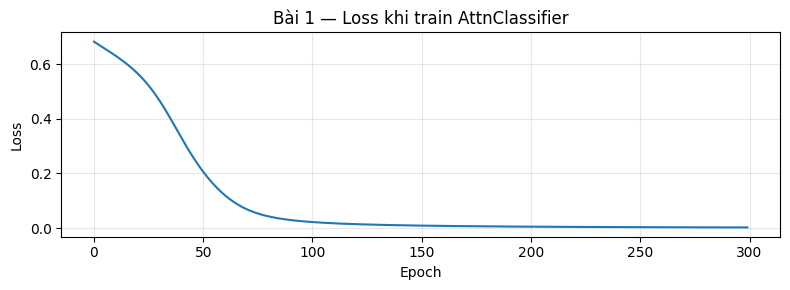

In [3]:
loss_hist = []
for epoch in range(300):
    model_b1.train()
    optimizer.zero_grad()
    logits = model_b1(X_raw)
    loss = criterion(logits, y)
    loss.backward()
    optimizer.step()
    loss_hist.append(loss.item())
    if (epoch + 1) % 60 == 0:
        acc = (logits.argmax(1) == y).float().mean().item()
        print(f'Epoch {epoch+1:3d}  loss = {loss.item():.4f}  acc = {acc*100:.2f}%')

plt.figure(figsize=(8, 3))
plt.plot(loss_hist)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(alpha=0.3)
plt.title('Bài 1 — Loss khi train AttnClassifier')
plt.tight_layout()
plt.show()

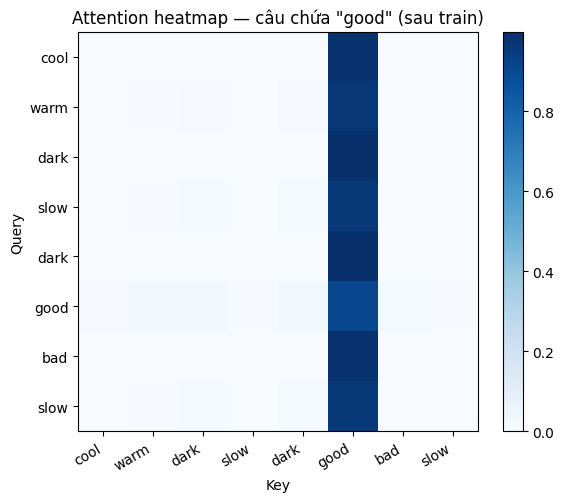

Attention trung bình nhận được:
  cool  : 0.003  
  warm  : 0.005  
  dark  : 0.007  
  slow  : 0.002  
  dark  : 0.007  
  good  : 0.971  ████████████████████████████████████████████████
  bad   : 0.003  
  slow  : 0.002  


In [4]:
model_b1.eval()

good_indices = (y == 1).nonzero(as_tuple=True)[0]
idx = good_indices[0].item()
sample = X_raw[idx].unsqueeze(0)
token_labels = [VOCAB[t] for t in sample[0].tolist()]

with torch.no_grad():
    _, attn_w = model_b1(sample, return_attn=True)

attn_map = attn_w[0].numpy()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(attn_map, cmap='Blues', vmin=0, vmax=attn_map.max())
ax.set_xticks(range(SEQ_LEN))
ax.set_xticklabels(token_labels, rotation=30, ha='right')
ax.set_yticks(range(SEQ_LEN))
ax.set_yticklabels(token_labels)
ax.set_xlabel('Key')
ax.set_ylabel('Query')
ax.set_title('Attention heatmap — câu chứa "good" (sau train)')
plt.colorbar(im)
plt.tight_layout()
plt.show()

avg_attn = attn_map.mean(axis=0)
print('Attention trung bình nhận được:')
for tok, score in zip(token_labels, avg_attn):
    bar = '█' * int(score * 50)
    print(f'  {tok:6s}: {score:.3f}  {bar}')

### Nhận xét Bài 1

Token `good` có attention score trung bình **0.971**, cao hơn tất cả các token còn lại
(cao nhất trong số các token khác chỉ là 0.007).

Điều này cho thấy sau khi train, self-attention đã học được cách tập trung gần như
toàn bộ "trọng số chú ý" vào từ quyết định nhãn. Thay vì xử lý đều tất cả token
như bag-of-words, cơ chế attention tự động phát hiện token nào mang tín hiệu phân
loại quan trọng nhất — đây chính là lý do Transformer hiệu quả hơn các phương pháp
trước đó trong NLP.


## Bài 2: So sánh Transformer với LSTM

In [5]:
import time

torch.manual_seed(0)
NUM_CLASSES = 5
SEQ_LEN_2 = 30
N2 = 500

X2 = torch.randint(0, NUM_CLASSES, (N2, SEQ_LEN_2))
y2 = X2[:, 0]

split = int(0.8 * N2)
X_train, X_test = X2[:split], X2[split:]
y_train, y_test = y2[:split], y2[split:]

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: torch.Size([400, 30]), Test: torch.Size([100, 30])


In [6]:
class TransformerLongDep(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, num_heads=4,
                 ffn_dim=64, num_layers=2, num_classes=5, max_len=40):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, embed_dim)
        self.pos_emb = nn.Embedding(max_len, embed_dim)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=ffn_dim, dropout=0.1, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        pos = torch.arange(x.size(1), device=x.device).unsqueeze(0)
        h = self.token_emb(x) + self.pos_emb(pos)
        h = self.encoder(h)
        return self.fc(h.mean(dim=1))


model_tf = TransformerLongDep(vocab_size=NUM_CLASSES)
opt_tf = torch.optim.Adam(model_tf.parameters(), lr=1e-3)
crit = nn.CrossEntropyLoss()

EPOCHS = 100
tf_loss_hist = []
epoch_times = []

for epoch in range(EPOCHS):
    t0 = time.time()
    model_tf.train()
    opt_tf.zero_grad()
    logits = model_tf(X_train)
    loss = crit(logits, y_train)
    loss.backward()
    opt_tf.step()
    epoch_times.append(time.time() - t0)
    tf_loss_hist.append(loss.item())

model_tf.eval()
with torch.no_grad():
    tf_acc = (model_tf(X_test).argmax(1) == y_test).float().mean().item()

avg_epoch_time = np.mean(epoch_times) * 1000
print(f'Transformer — Test Accuracy : {tf_acc*100:.2f}%')
print(f'Transformer — Avg epoch time: {avg_epoch_time:.2f} ms')

Transformer — Test Accuracy : 100.00%
Transformer — Avg epoch time: 46.83 ms


In [7]:
class LSTMLongDep(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden=64, num_classes=5):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, num_classes)

    def forward(self, x):
        h, _ = self.lstm(self.emb(x))
        return self.fc(h[:, -1, :])


model_lstm = LSTMLongDep(vocab_size=NUM_CLASSES)
opt_lstm = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)
lstm_loss_hist = []
lstm_times = []

for epoch in range(EPOCHS):
    t0 = time.time()
    model_lstm.train()
    opt_lstm.zero_grad()
    logits = model_lstm(X_train)
    loss = crit(logits, y_train)
    loss.backward()
    opt_lstm.step()
    lstm_times.append(time.time() - t0)
    lstm_loss_hist.append(loss.item())

model_lstm.eval()
with torch.no_grad():
    lstm_acc = (model_lstm(X_test).argmax(1) == y_test).float().mean().item()

avg_lstm_time = np.mean(lstm_times) * 1000
print(f'LSTM        — Test Accuracy : {lstm_acc*100:.2f}%')
print(f'LSTM        — Avg epoch time: {avg_lstm_time:.2f} ms')

LSTM        — Test Accuracy : 61.00%
LSTM        — Avg epoch time: 12.23 ms


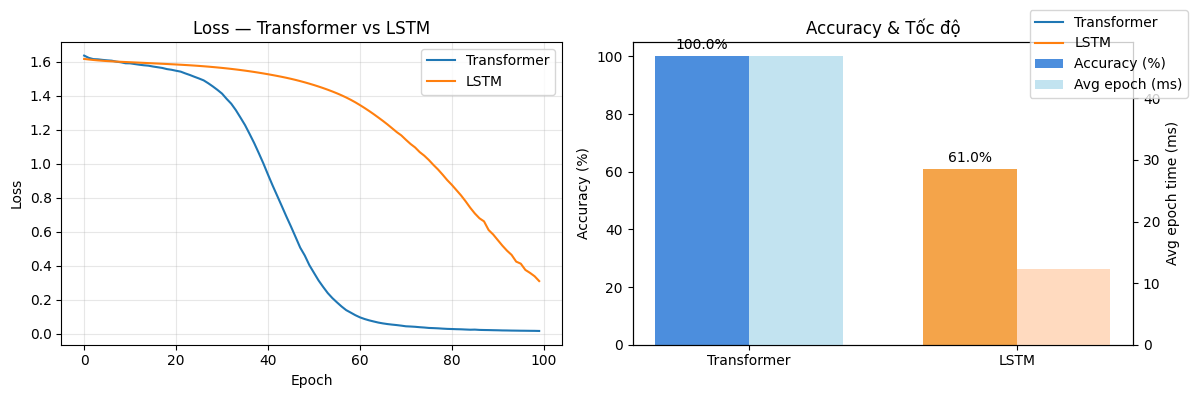

Transformer: acc=100.00%  |  avg epoch=46.83ms
LSTM       : acc=61.00%  |  avg epoch=12.23ms


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(tf_loss_hist, label='Transformer')
axes[0].plot(lstm_loss_hist, label='LSTM')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss — Transformer vs LSTM')
axes[0].legend()
axes[0].grid(alpha=0.3)

x = np.arange(2)
w = 0.35
accs = [tf_acc * 100, lstm_acc * 100]
times = [avg_epoch_time, avg_lstm_time]
ax2 = axes[1]
bars1 = ax2.bar(x - w/2, accs, w, label='Accuracy (%)', color=['#4c8edd', '#f4a44a'])
ax2.set_ylabel('Accuracy (%)')
ax2_right = ax2.twinx()
ax2_right.bar(x + w/2, times, w, label='Avg epoch (ms)', color=['#a8d8ea', '#ffcba4'], alpha=0.7)
ax2_right.set_ylabel('Avg epoch time (ms)')
ax2.set_xticks(x)
ax2.set_xticklabels(['Transformer', 'LSTM'])
ax2.set_title('Accuracy & Tốc độ')
ax2.bar_label(bars1, fmt='%.1f%%', padding=3)
fig.legend(loc='upper right', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

print(f'Transformer: acc={tf_acc*100:.2f}%  |  avg epoch={avg_epoch_time:.2f}ms')
print(f'LSTM       : acc={lstm_acc*100:.2f}%  |  avg epoch={avg_lstm_time:.2f}ms')

### Nhận xét Bài 2

**Accuracy:** Transformer đạt **100%**, LSTM chỉ đạt **61%**. Task này yêu cầu nhớ
token đầu tiên trong chuỗi 30 token — đây là bài toán long-range dependency điển hình.
Transformer xử lý tốt vì self-attention nhìn trực tiếp toàn bộ chuỗi cùng lúc, nên
khoảng cách giữa token đầu và token cuối không gây khó khăn. LSTM phải truyền thông
tin qua 30 bước tuần tự nên dễ bị "quên" dù đã có cơ chế gate.

**Tốc độ:** LSTM nhanh hơn đáng kể — **12.23ms/epoch** so với **46.83ms/epoch** của
Transformer. Điều này không bất ngờ trên CPU: Transformer có lợi thế song song hoá
nhưng lợi thế đó chỉ thể hiện rõ trên GPU. Trên CPU với batch nhỏ, chi phí tính toán
ma trận attention (O(n²)) lớn hơn chi phí tuần tự của LSTM.


## Bài 3: Fine-tune BERT (nâng cao)

```bash
pip install transformers datasets accelerate
```

In [9]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset

model_name = 'distilbert-base-uncased'
dataset = load_dataset('stanfordnlp/imdb')

tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, padding='max_length', max_length=256)

dataset = dataset.map(tokenize, batched=True)
dataset = dataset.rename_column('label', 'labels')
dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

model_bert = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    eval_strategy='epoch',      
    learning_rate=2e-5,
    save_strategy='no',
    report_to='none'
)

trainer = Trainer(
    model=model_bert,
    args=args,
    train_dataset=dataset['train'].shuffle(seed=42).select(range(2000)),
    eval_dataset=dataset['test'].select(range(500))
)

trainer.train()

/Users/tandoan/Dev/HUIT/Deeplearning/Deep-Learning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 100/100 [00:00<00:00, 16249.43it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect i

Epoch,Training Loss,Validation Loss
1,No log,0.412669
2,No log,0.274747


TrainOutput(global_step=250, training_loss=0.354686767578125, metrics={'train_runtime': 177.8915, 'train_samples_per_second': 22.486, 'train_steps_per_second': 1.405, 'total_flos': 264934797312000.0, 'train_loss': 0.354686767578125, 'epoch': 2.0})

In [10]:
from transformers import pipeline

clf = pipeline('text-classification', model=model_bert, tokenizer=tokenizer)

examples = [
    'This movie is absolutely amazing, best film I have ever seen!',
    'Totally boring and a waste of time.',
    'The acting was decent but the plot was terrible.',
    'A masterpiece of modern cinema.',
    'I fell asleep halfway through, very disappointing.',
]

for ex in examples:
    result = clf(ex)[0]
    print(f'"{ex[:50]}..."  →  {result["label"]}  (score={result["score"]:.2f})')

"This movie is absolutely amazing, best film I have..."  →  LABEL_1  (score=0.95)
"Totally boring and a waste of time...."  →  LABEL_0  (score=0.95)
"The acting was decent but the plot was terrible...."  →  LABEL_0  (score=0.93)
"A masterpiece of modern cinema...."  →  LABEL_1  (score=0.90)
"I fell asleep halfway through, very disappointing...."  →  LABEL_0  (score=0.89)


## Bài 4: Đọc paper "Attention Is All You Need"

Paper: https://arxiv.org/abs/1706.03762

**Câu 1: Transformer ban đầu được thiết kế cho task gì?**

> Transformer được thiết kế cho task dịch máy (machine translation) — cụ thể là dịch Anh-Đức và Anh-Pháp. Đây là seq2seq task, không phải classification.

**Câu 2: Encoder và Decoder khác nhau ở chỗ nào?**

> Encoder chỉ có self-attention để encode chuỗi đầu vào. Decoder có thêm một tầng cross-attention ở giữa — nhận Q từ Decoder, K và V từ output của Encoder — để "nhìn" vào chuỗi nguồn khi sinh từng token đầu ra. Ngoài ra Decoder dùng masked self-attention thay vì self-attention thông thường.

**Câu 3: "Masked self-attention" trong Decoder để làm gì?**

> Masked self-attention đảm bảo khi sinh token ở vị trí tt
t, Decoder chỉ nhìn được các token đã sinh trước đó (vị trí 1 đến t−1t-1
t−1), không được nhìn các token tương lai. Mask này được thực hiện bằng cách đặt các vị trí tương lai về −∞-\infty
−∞ trước khi softmax, khiến attention weight tại đó bằng 0.
